# Final Comparison of Supervised and Unsupervised Learning

This notebook brings together the main results from the previous breast cancer morphology analyses.

The goal is not to retrain every model again. Instead, the notebook compares the results already obtained from:

- Logistic Regression
- SVM
- Random Forest
- K-Means
- Hierarchical Clustering
- Gaussian Mixture Model (GMM)
- Feature selection and PCA

Supervised and unsupervised methods are compared separately because their evaluation metrics answer different questions.


## 1. Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Supervised model comparison

All three supervised models were evaluated on the same held-out test set.

Sensitivity measures how well malignant cases are detected, while specificity measures how well benign cases are recognised. ROC-AUC evaluates ranking performance across classification thresholds.


In [ ]:
supervised_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [0.9649, 0.9737, 0.9737],
    "Sensitivity": [0.9286, 0.9286, 0.9286],
    "Specificity": [0.9861, 1.0000, 1.0000],
    "F1": [0.9512, 0.9630, 0.9630],
    "ROC_AUC": [0.9960, 0.9957, 0.9967]
})

supervised_results.round(4)


,Model,Accuracy,Sensitivity,Specificity,F1,ROC_AUC
0,Logistic Regression,0.9649,0.9286,0.9861,0.9512,0.9960
1,SVM,0.9737,0.9286,1.0000,0.9630,0.9957
2,Random Forest,0.9737,0.9286,1.0000,0.9630,0.9967


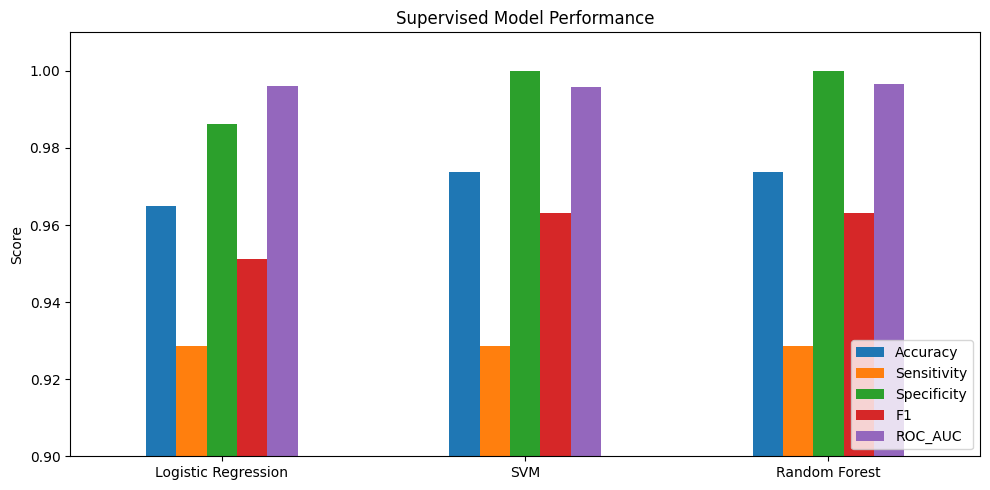

In [ ]:
plot_supervised = supervised_results.set_index("Model")[
    ["Accuracy", "Sensitivity", "Specificity", "F1", "ROC_AUC"]
]

plot_supervised.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Score")
plt.xlabel("")
plt.title("Supervised Model Performance")
plt.ylim(0.90, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretation

The three supervised models perform very similarly on this test split. Logistic Regression already gives very strong discrimination, while SVM and Random Forest both classify 111 of the 114 test samples correctly.

Random Forest has the highest observed ROC-AUC of the three, but the differences are very small. This means the dataset is already highly separable using these morphology measurements, and a more complex model does not produce a large improvement over the simpler linear model.


## 3. Unsupervised clustering comparison

Clustering is evaluated separately because these methods do not use diagnosis labels during training.

ARI and NMI measure how closely the discovered clusters agree with the known diagnosis after clustering. Silhouette measures how compact and separated the clusters are using only the feature space.


In [ ]:
unsupervised_results = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical", "GMM"],
    "ARI": [0.6707, 0.5750, 0.6779],
    "NMI": [0.5546, 0.4569, 0.5603],
    "Silhouette": [0.3450, 0.3394, 0.3157]
})

unsupervised_results.round(4)


,Method,ARI,NMI,Silhouette
0,K-Means,0.6707,0.5546,0.3450
1,Hierarchical,0.5750,0.4569,0.3394
2,GMM,0.6779,0.5603,0.3157


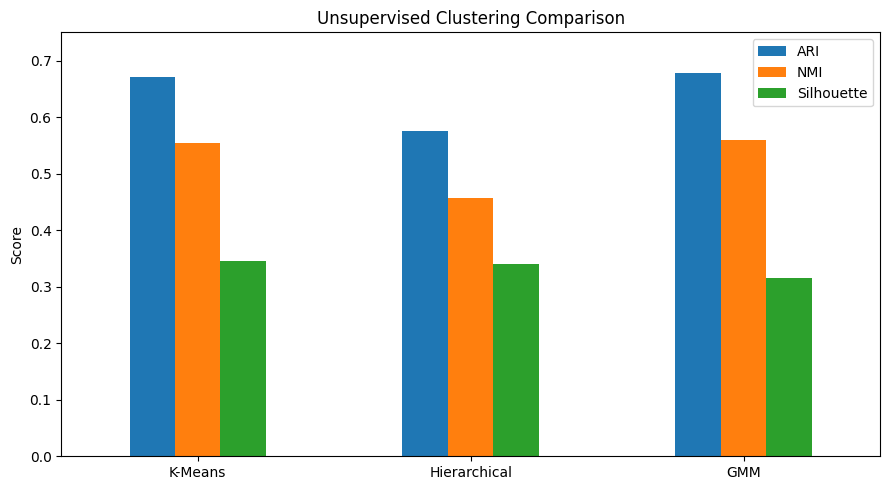

In [ ]:
plot_unsupervised = unsupervised_results.set_index("Method")

plot_unsupervised.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Score")
plt.xlabel("")
plt.title("Unsupervised Clustering Comparison")
plt.ylim(0, 0.75)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretation

The clustering methods recover meaningful structure related to diagnosis, but the agreement is not perfect.

K-Means and GMM have very similar agreement with the true diagnosis. GMM gives the highest observed ARI and NMI, while K-Means gives the highest silhouette score. Hierarchical clustering shows weaker agreement with diagnosis than the other two methods.

This difference is expected: unsupervised algorithms are trying to discover natural structure in the morphology data without being told which samples are benign or malignant.


## Cross-validation: checking whether the results are stable

The previous comparisons used one fixed train/test split. That is useful for a final held-out evaluation, but a single split can sometimes make a model look slightly better or worse by chance.

Here, 5-fold stratified cross-validation is used to check whether the supervised results remain consistent across different subsets of the data. Scaling and PCA are placed inside pipelines so that each fold is processed independently and information from the validation fold does not leak into training.


In [ ]:
# Reproducible data loading
# Use breast_cancer.csv when it is available; otherwise rebuild the same
# Wisconsin diagnostic dataset from scikit-learn so "Run all" works cleanly.
from pathlib import Path
import numpy as np
import pandas as pd

def load_project_data():
    candidates = [
        Path("breast_cancer.csv"),
        Path("/content/breast_cancer.csv"),
        Path("/mnt/data/breast_cancer.csv"),
    ]
    for path in candidates:
        if path.exists():
            data = pd.read_csv(path)
            data.columns = data.columns.str.strip()
            if {"id", "diagnosis"}.issubset(data.columns):
                print(f"Loaded: {path}")
                return data

    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer(as_frame=True)
    features = raw.data.copy()

    def project_name(name):
        if name.startswith("mean "):
            return name[5:].replace(" ", "_") + "_mean"
        if name.endswith(" error"):
            return name[:-6].replace(" ", "_") + "_se"
        if name.startswith("worst "):
            return name[6:].replace(" ", "_") + "_worst"
        return name.replace(" ", "_")

    features.columns = [project_name(c) for c in features.columns]
    data = features.copy()
    data.insert(0, "id", np.arange(1, len(data) + 1))
    data.insert(1, "diagnosis", np.where(raw.target.to_numpy() == 0, "M", "B"))
    print("breast_cancer.csv not found; loaded the equivalent scikit-learn dataset.")
    return data

df = load_project_data()
print("Dataset shape:", df.shape)

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts().sort_index())


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# X and y should contain the 30 morphology features and diagnosis labels
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={"Accuracy": "accuracy", "ROC_AUC": "roc_auc"}
    )

    rows.append({
        "Model": name,
        "Accuracy mean": scores["test_Accuracy"].mean(),
        "Accuracy SD": scores["test_Accuracy"].std(),
        "ROC_AUC mean": scores["test_ROC_AUC"].mean(),
        "ROC_AUC SD": scores["test_ROC_AUC"].std()
    })

cv_results = pd.DataFrame(rows)
cv_results.round(4)


,Model,Accuracy mean,Accuracy SD,ROC_AUC mean,ROC_AUC SD
0,Logistic Regression,0.9737,0.0166,0.9953,0.0053
1,SVM,0.9772,0.0163,0.9945,0.0060
2,Random Forest,0.9526,0.0131,0.9895,0.0077


The mean gives the average performance across the five folds, while the standard deviation shows how much the result changes between folds. Small standard deviations would support the conclusion that the strong supervised performance is not dependent on only one train/test split.


In [ ]:
# Compare full features, Worst features and PCA using the same classifier

worst_cols = [col for col in X.columns if col.endswith("_worst")]

representations = {
    "All 30 features": (
        X,
        Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=42))
        ])
    ),
    "Worst 10 features": (
        X[worst_cols],
        Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=42))
        ])
    ),
    "PCA - 7 components": (
        X,
        Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=7)),
            ("model", LogisticRegression(max_iter=2000, random_state=42))
        ])
    )
}

rows = []

for name, (X_part, model) in representations.items():
    scores = cross_validate(
        model,
        X_part,
        y,
        cv=cv,
        scoring={"Accuracy": "accuracy", "ROC_AUC": "roc_auc"}
    )

    rows.append({
        "Representation": name,
        "Accuracy mean": scores["test_Accuracy"].mean(),
        "Accuracy SD": scores["test_Accuracy"].std(),
        "ROC_AUC mean": scores["test_ROC_AUC"].mean(),
        "ROC_AUC SD": scores["test_ROC_AUC"].std()
    })

cv_feature_results = pd.DataFrame(rows)
cv_feature_results.round(4)


,Representation,Accuracy mean,Accuracy SD,ROC_AUC mean,ROC_AUC SD
0,All 30 features,0.9737,0.0166,0.9953,0.0053
1,Worst 10 features,0.9789,0.0119,0.9935,0.0081
2,PCA - 7 components,0.9614,0.0153,0.9946,0.0045


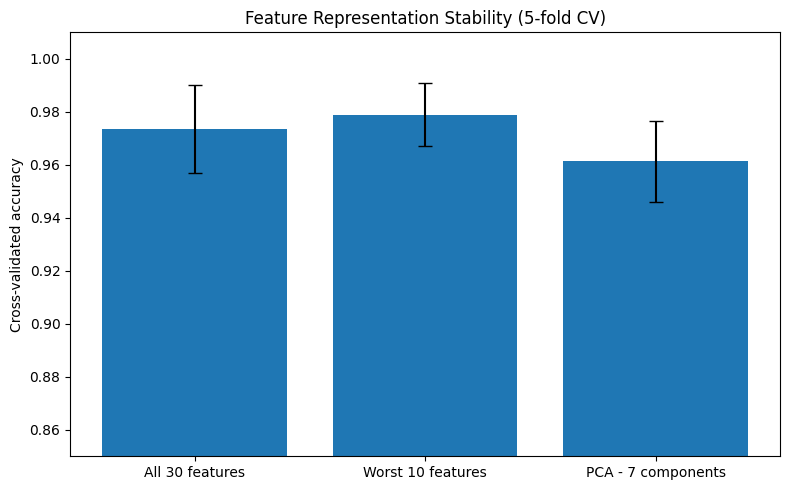

In [ ]:
# Visual check of cross-validated accuracy

plot_cv = cv_feature_results.set_index("Representation")

plt.figure(figsize=(8, 5))
plt.bar(
    plot_cv.index,
    plot_cv["Accuracy mean"],
    yerr=plot_cv["Accuracy SD"],
    capsize=5
)

plt.ylabel("Cross-validated accuracy")
plt.title("Feature Representation Stability (5-fold CV)")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Why this matters

The fixed test set remains useful as the final held-out comparison. Cross-validation adds a second check: it shows whether the same pattern is reasonably stable when the training/validation partition changes.

The cross-validation results should therefore be interpreted together with the original test-set results rather than replacing them.


## 4. Feature selection and PCA

The feature-selection notebook showed that the different groups of morphology measurements do not contribute equally.

The strongest supervised result came from the 10 Worst features. PCA also showed that the original 30 variables are highly redundant.


In [ ]:
feature_representation = pd.DataFrame({
    "Representation": [
        "All 30 features",
        "Worst 10 features",
        "PCA - 7 components"
    ],
    "Accuracy": [0.9649, 0.9912, 0.9737],
    "ROC_AUC": [0.9960, 0.9970, 0.9967]
})

feature_representation.round(4)


,Representation,Accuracy,ROC_AUC
0,All 30 features,0.9649,0.9960
1,Worst 10 features,0.9912,0.9970
2,PCA - 7 components,0.9737,0.9967


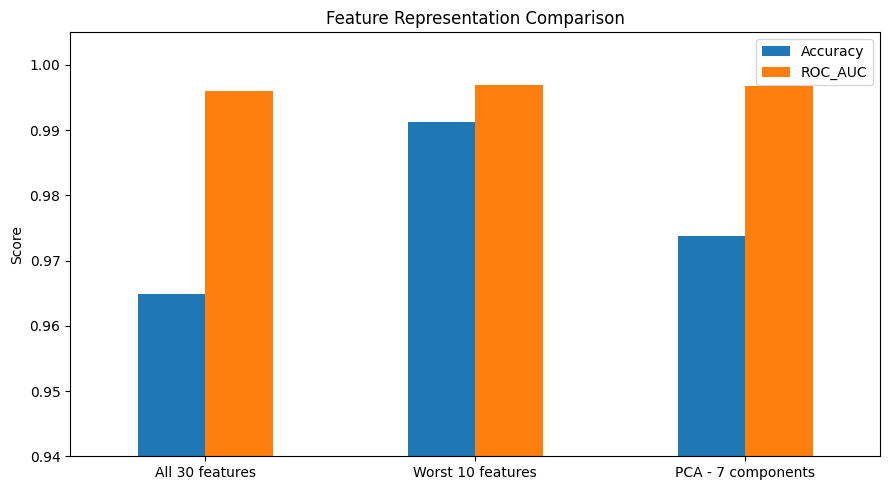

In [ ]:
feature_representation.set_index("Representation").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.xlabel("")
plt.title("Feature Representation Comparison")
plt.ylim(0.94, 1.005)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### PCA summary

Using all 30 standardized features:

- PC1 explained **44.59%** of the variance.
- PC1 + PC2 explained **63.14%**.
- **7 principal components** retained about **90%** of the total variance.
- **10 principal components** retained about **95%**.

Using only the Worst 10 features:

- PC1 explained **57.15%** of the variance.
- PC1 + PC2 explained **77.88%**.

The Worst measurements therefore contain a more concentrated low-dimensional structure than the full 30-feature set.


## 5. Features that repeatedly appear as important

Across ANOVA ranking, supervised model importance and PCA loadings, the same morphology themes appeared repeatedly:

- concave points
- concavity
- radius
- perimeter
- area
- compactness

Many of these measurements appear in their Mean or Worst form.

This consistency across different methods suggests that tumour size and boundary irregularity are major sources of variation and diagnostic separation in this dataset.


In [ ]:
important_features = pd.DataFrame({
    "Feature": [
        "concave_points_mean",
        "concavity_mean",
        "concave_points_worst",
        "compactness_mean",
        "perimeter_worst",
        "radius_worst",
        "concavity_worst",
        "perimeter_mean",
        "area_worst",
        "area_mean"
    ],
    "Absolute_PC1_loading": [
        0.260383,
        0.257761,
        0.249367,
        0.241928,
        0.235494,
        0.226607,
        0.226322,
        0.225804,
        0.223108,
        0.219079
    ]
})

important_features


,Feature,Absolute_PC1_loading
0,concave_points_mean,0.260383
1,concavity_mean,0.257761
2,concave_points_worst,0.249367
3,compactness_mean,0.241928
4,perimeter_worst,0.235494
5,radius_worst,0.226607
6,concavity_worst,0.226322
7,perimeter_mean,0.225804
8,area_worst,0.223108
9,area_mean,0.219079


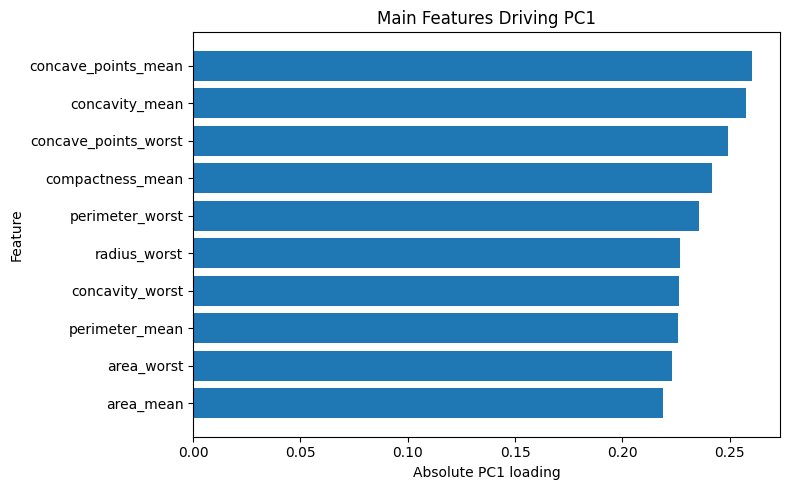

In [ ]:
plot_features = important_features.sort_values("Absolute_PC1_loading")

plt.figure(figsize=(8, 5))
plt.barh(plot_features["Feature"], plot_features["Absolute_PC1_loading"])
plt.xlabel("Absolute PC1 loading")
plt.ylabel("Feature")
plt.title("Main Features Driving PC1")
plt.tight_layout()
plt.show()


## 6. Supervised versus unsupervised view

The supervised models use diagnosis labels directly and therefore answer a prediction question: how accurately can diagnosis be estimated from the morphology measurements?

The clustering methods do not use the diagnosis labels. They answer a different question: does the morphology data naturally form groups that resemble the diagnostic classes?

The results show both effects. Supervised prediction is extremely strong, while unsupervised clustering shows substantial but incomplete alignment with diagnosis. This suggests that benign and malignant samples occupy different regions of the morphology space, although their natural structure is not perfectly divided into two completely separate groups.


# Final Research Conclusion

## Research Question

**To what extent do supervised and unsupervised learning methods reveal consistent diagnostic structure in breast-tumour morphology, and can this structure be represented using a smaller subset of morphological features?**

## Conclusion

This project investigated breast-tumour morphology using supervised learning, unsupervised learning, feature selection and dimensionality reduction.

The supervised models showed that the morphology measurements contain a strong signal associated with diagnosis. On the fixed test set, Logistic Regression, SVM and Random Forest all achieved high predictive performance.

To check whether these results depended on a particular train/test split, 5-fold stratified cross-validation was also performed. Logistic Regression achieved a mean accuracy of **97.37% ± 1.66%** with a mean ROC-AUC of **0.9953**. SVM achieved **97.72% ± 1.63%** accuracy and **0.9945 ROC-AUC**, while Random Forest achieved **95.26% ± 1.31%** accuracy and **0.9895 ROC-AUC**. The strong performance across multiple folds shows that the supervised results were reasonably stable and were not limited to a single test split.

The unsupervised analysis provided a complementary view of the same data. K-Means, Hierarchical Clustering and GMM recovered meaningful structure related to diagnosis even though diagnosis labels were not used during clustering. However, this correspondence was incomplete. This suggests that benign and malignant samples occupy different regions of the morphology space, but the natural structure of the data is not perfectly divided into two diagnostic groups.

Feature analysis showed a consistent pattern across different methods. Measurements related to **concave points, concavity, radius, perimeter, area and compactness** repeatedly appeared as important. Their repeated appearance across ANOVA, supervised feature importance and PCA suggests that tumour size and boundary irregularity are major sources of variation associated with diagnosis in this dataset.

The Mean, SE and Worst feature analysis showed that the Worst measurements were particularly informative. On the original fixed test split, Logistic Regression using only the 10 Worst features achieved **99.12% accuracy and 0.9970 ROC-AUC**.

Cross-validation provided a more robust comparison. The Worst 10 features achieved the highest mean cross-validated accuracy at **97.89% ± 1.19%**, compared with **97.37% ± 1.66%** using all 30 features. However, all 30 features produced a slightly higher mean ROC-AUC (**0.9953**) than the Worst 10 (**0.9935**). Therefore, the results do not show that the Worst features are universally superior. Instead, they show that a much smaller set of 10 measurements can retain performance comparable to the complete 30-feature representation.

PCA demonstrated substantial redundancy among the original measurements. Seven principal components retained approximately **90% of the total variance**. Using these 7 components, Logistic Regression achieved a cross-validated accuracy of **96.14% ± 1.53%** and a ROC-AUC of **0.9946**. Therefore, PCA reduced the dimensionality from 30 variables to 7 while preserving most of the predictive information.

Overall, the supervised, unsupervised and dimensionality-reduction analyses point towards a consistent underlying result: **breast-tumour morphology contains strong structure associated with diagnosis, much of this information is concentrated in a smaller number of correlated measurements, and reduced representations can preserve most of the useful information contained in the complete feature set.**

Importantly, the purpose of this project is not to identify a single "best" algorithm. The more interesting result is the agreement between different analytical approaches. Supervised models showed strong predictive separation, unsupervised methods independently recovered part of the same structure, and feature-selection and PCA analyses identified recurring morphological characteristics underlying this separation.

## Limitations

These results describe this dataset and should not be interpreted as evidence of clinical diagnostic performance. The dataset contains only 569 observations, many of the morphology variables are strongly correlated, and no independent external clinical dataset was used for validation. Cross-validation improves confidence in the internal stability of the results, but external validation would still be necessary before making conclusions about generalisation to other populations or clinical settings.

## Final Answer to the Research Question

The results provide evidence that supervised and unsupervised learning methods reveal broadly consistent structure in breast-tumour morphology. Supervised models can use this structure for highly accurate classification within the dataset, while clustering methods recover part of the same separation without access to diagnosis labels.

Furthermore, the diagnostic structure does not require all 30 original measurements to be represented effectively. Ten Worst morphology features achieved performance comparable to the complete feature set, while seven PCA components retained approximately 90% of the variance and maintained strong predictive performance.

Therefore, the main finding of this project is that **the diagnostic information present in breast-tumour morphology is strong, structured and substantially redundant, with measurements related to tumour size and boundary irregularity contributing prominently to the observed separation between benign and malignant samples.**